# Eksperimen Model Global LSTM (All Categories - 3 Juta Data)
Notebook ini melatih dan mengevaluasi **4 Arsitektur Model Global LSTM** menggunakan **seluruh 3.000.888 baris data dari `train.csv`** yang mencakup **1.782 kombinasi Store-Family** dari ke-5 kategori pola permintaan (*Smooth*, *Intermittent*, *Lumpy*, *Erratic*, dan *No Sales*):
1. **Simple Univariate LSTM** (1 Layer LSTM)
2. **Complex Univariate LSTM** (2 Layer LSTM + Dropout + Dense Projection)
3. **Simple Multivariate LSTM** (1 Layer LSTM + 11 Fitur)
4. **Complex Multivariate LSTM** (2 Layer LSTM + Dropout + Dense Projection + 11 Fitur)

Evaluasi dan visualisasi difokuskan pada **8 Kombinasi Target** (mencakup berbagai kategori seperti *Smooth* dan *Erratic* pada Store 44) serta analisis agregat rata-rata RMSLE per-kategori permintaan.


In [ ]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.preprocessing import MinMaxScaler  

np.random.seed(10122097)


In [ ]:
train = pd.read_csv('../datasets/train.csv', parse_dates=['date']).drop(columns='id')
transactions = pd.read_csv('../datasets/transactions.csv', parse_dates=['date'])
df_full_stats = pd.read_csv('descriptive_stats_all_combinations.csv')
stores = pd.read_csv('../datasets/stores.csv')


### 1. Pemilihan Data & Pembentukan Sequence Univariat (All Categories)
Pada tahap ini, kita mengambil seluruh 1.782 kombinasi Store-Family dari semua kategori pola permintaan (*Smooth, Intermittent, Lumpy, Erratic, No Sales*). Data dipivot secara efisien dan dinormalisasi menggunakan per-series `MinMaxScaler` sebelum dibentuk menjadi *sliding window sequence* ($TIME\_STEPS = 14$).


In [ ]:
# Menggunakan seluruh 1.782 kombinasi store-family dari semua 5 kategori
all_combinations = df_full_stats[['store_nbr', 'family', 'category']].copy()
print(f"Total kombinasi yang digunakan: {len(all_combinations)}")
print("Distribusi kategori kombinasi:")
print(all_combinations['category'].value_counts())

TIME_STEPS = 14

# Pivot data penjualan untuk seluruh kombinasi secara cepat
pivoted_sales = train.pivot(index='date', columns=['store_nbr', 'family'], values='sales').asfreq('D').fillna(0)
dates = pivoted_sales.index

pooled_X, pooled_y = [], []
series_scalers = {}
combo_slice_indices = {} # Pemetaan indeks per-kombinasi: (start_idx, split_idx, end_idx)

current_idx = 0
for store, family in all_combinations[['store_nbr', 'family']].itertuples(index=False):
    sales = pivoted_sales[(store, family)].values
    
    # Normalisasi per-series (invarian skala toko/family)
    scaler = MinMaxScaler()
    sales_scaled = scaler.fit_transform(sales.reshape(-1, 1)).flatten()
    series_scalers[(store, family)] = scaler
    
    n_seq = len(sales_scaled) - TIME_STEPS
    start_seq_idx = current_idx
    split_seq_idx = current_idx + int(n_seq * 0.8)
    end_seq_idx = current_idx + n_seq
    combo_slice_indices[(store, family)] = (start_seq_idx, split_seq_idx, end_seq_idx)
    current_idx = end_seq_idx
    
    # Vectorized sliding window sequence generation
    windows = np.lib.stride_tricks.sliding_window_view(sales_scaled, TIME_STEPS + 1)
    pooled_X.append(windows[:, :-1])
    pooled_y.append(windows[:, -1])

pooled_X = np.concatenate(pooled_X, axis=0).reshape(-1, TIME_STEPS, 1).astype(np.float32)
pooled_y = np.concatenate(pooled_y, axis=0).astype(np.float32)

print(f"Total sequences hasil pooling: {len(pooled_X):,} dengan shape {pooled_X.shape}")
print(f"Ukuran memori array input X: {pooled_X.nbytes / (1024**2):.2f} MB")


In [ ]:
# Pembagian Data Train/Test Kronologis (80% Train, 20% Test) menggunakan slice terstruktur
train_slices, test_slices = [], []
for store, family in all_combinations[['store_nbr', 'family']].itertuples(index=False):
    start, split, end = combo_slice_indices[(store, family)]
    train_slices.append(np.arange(start, split))
    test_slices.append(np.arange(split, end))

train_idx = np.concatenate(train_slices)
test_idx = np.concatenate(test_slices)

X_train_pooled, y_train_pooled = pooled_X[train_idx], pooled_y[train_idx]
X_test_pooled, y_test_pooled = pooled_X[test_idx], pooled_y[test_idx]

print(f"Train sequences (80%): {len(X_train_pooled):,} | Test sequences (20%): {len(X_test_pooled):,}")


## 2. LSTM Univariat


### Eksperimen Model LSTM Univariat Sederhana (1 Layer)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_log_error


In [ ]:
# Membangun Arsitektur LSTM Sederhana (1 Layer)
model = Sequential([
    Input(shape=(TIME_STEPS, 1)),
    LSTM(64, activation='tanh', dropout=0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


In [ ]:
# Pelatihan Model Global Simple Univariate LSTM pada 2.38 Juta Data
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print(f"Memulai pelatihan model global untuk seluruh {len(all_combinations)} kombinasi ({len(X_train_pooled):,} sequences)...")
history = model.fit(
    X_train_pooled, y_train_pooled,
    validation_split=0.1,
    epochs=15,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)


### Evaluasi Performa Model Simple Univariate LSTM & Visualisasi (8 Kombinasi Target)


In [ ]:
# Fast Batch Evaluation untuk seluruh 1.782 kombinasi
print("Menjalankan inferensi batch untuk seluruh data test...")
y_test_pred_scaled = model.predict(X_test_pooled, batch_size=2048, verbose=1).flatten()

results = []
plot_data_uv = {}

test_offset = 0
for idx, (store, family, cat) in enumerate(all_combinations.itertuples(index=False)):
    start, split, end = combo_slice_indices[(store, family)]
    n_test_combo = end - split
    
    if n_test_combo == 0:
        continue
    
    # Ambil bagian prediksi dan aktual untuk kombinasi ini
    y_pred_scaled_combo = y_test_pred_scaled[test_offset : test_offset + n_test_combo]
    y_test_scaled_combo = y_test_pooled[test_offset : test_offset + n_test_combo]
    test_offset += n_test_combo
    
    # Inverse transform
    scaler = series_scalers[(store, family)]
    y_pred = scaler.inverse_transform(y_pred_scaled_combo.reshape(-1, 1)).flatten()
    y_test_combo = scaler.inverse_transform(y_test_scaled_combo.reshape(-1, 1)).flatten()
    
    # Hitung metrik RMSLE numerik stabil
    y_test_safe = np.maximum(0, y_test_combo)
    y_pred_safe = np.maximum(0, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_test_safe, y_pred_safe))
    
    results.append({
        'store_nbr': store,
        'family': family,
        'category': cat,
        'RMSLE': rmsle
    })
    plot_data_uv[(store, family)] = (y_test_combo, y_pred)

results_df = pd.DataFrame(results)
print("\n--- Rangkuman Evaluasi Keseluruhan (1.782 Kombinasi) ---")
display(results_df[['RMSLE']].describe())

print("\n--- Rata-rata RMSLE per Kategori Pola Permintaan ---")
display(results_df.groupby('category')['RMSLE'].agg(['count', 'mean', 'median', 'std', 'min', 'max']))


Hasil Evaluasi untuk 8 Kombinasi Target (Simple Univariate LSTM):


,store_nbr,family,category,RMSLE
505,23,EGGS,Smooth,0.410056
1641,54,MEATS,Smooth,0.409536
359,19,PREPARED FOODS,Smooth,0.417851
1715,7,SEAFOOD,Smooth,0.421428
524,23,PREPARED FOODS,Smooth,0.426994
1266,44,GROCERY I,Smooth,0.776069
1268,44,HARDWARE,Erratic,0.597321
1274,44,LAWN AND GARDEN,Erratic,0.597753


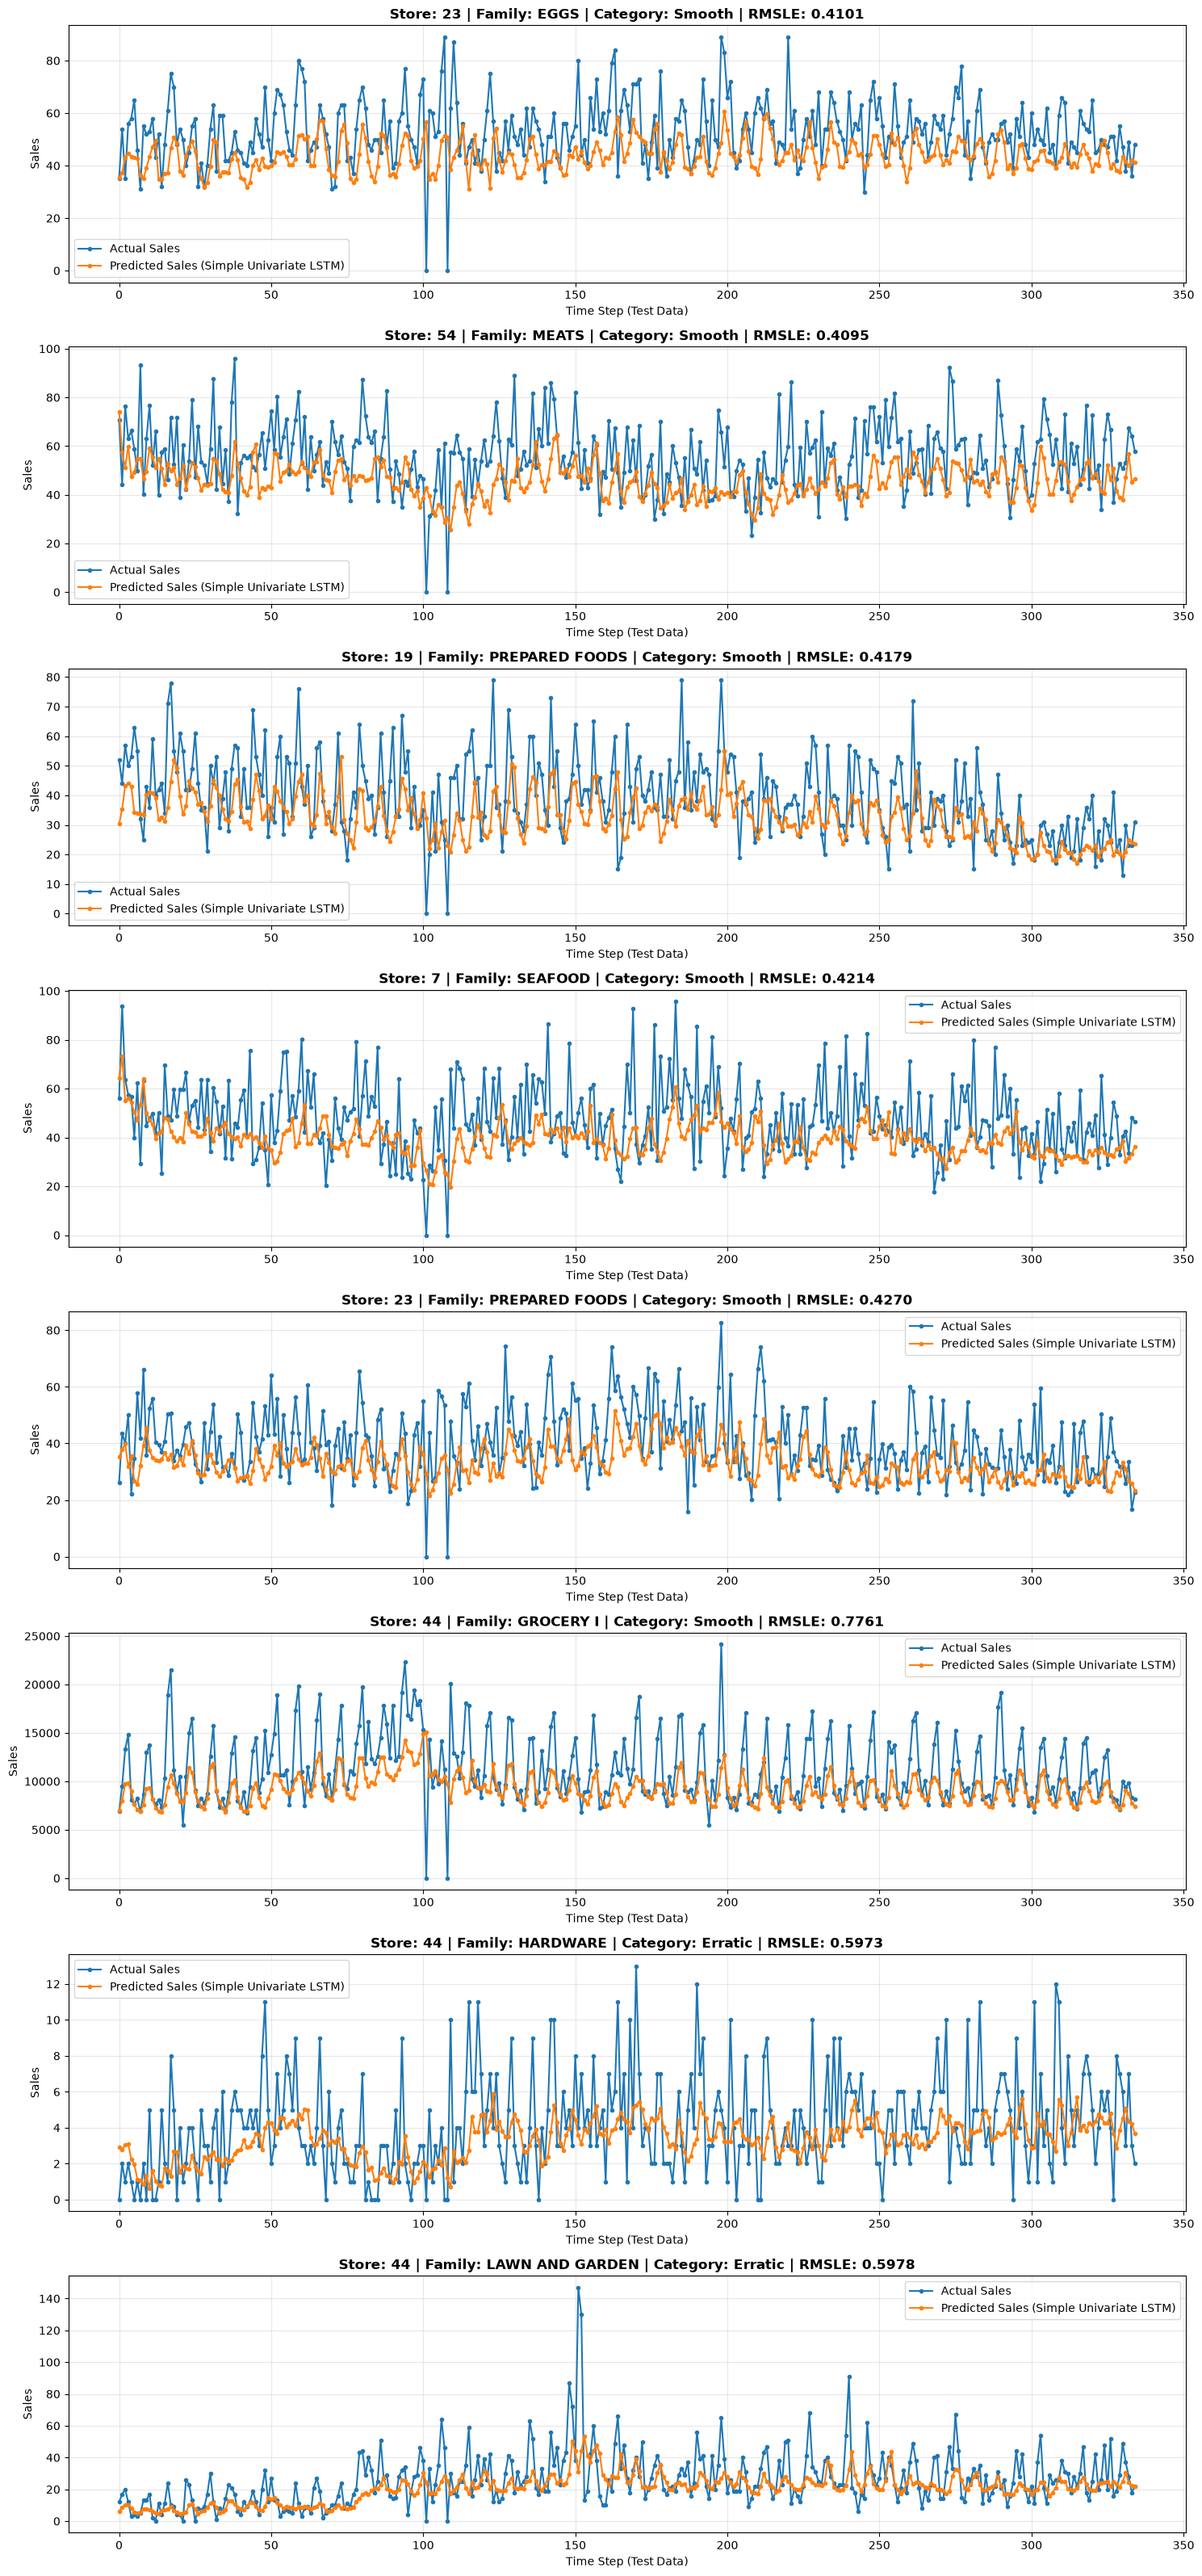

In [27]:
# 8 Kombinasi Store dan Family yang difokuskan (Termasuk Store 44 HARDWARE & LAWN AND GARDEN)
target_combos = [
    (23, 'EGGS'),
    (54, 'MEATS'),
    (19, 'PREPARED FOODS'),
    (7, 'SEAFOOD'),
    (23, 'PREPARED FOODS'),
    (44, 'GROCERY I'),
    (44, 'HARDWARE'),
    (44, 'LAWN AND GARDEN')
]

# Menampilkan hasil evaluasi RMSLE untuk 8 kombinasi target
selected_rows_uv = []
for store, family in target_combos:
    row = results_df[(results_df['store_nbr'] == store) & (results_df['family'] == family)]
    if not row.empty:
        selected_rows_uv.append(row.iloc[0])

target_results_uv_df = pd.DataFrame(selected_rows_uv)
print("Hasil Evaluasi untuk 8 Kombinasi Target (Simple Univariate LSTM):")
display(target_results_uv_df)

# Visualisasi plot validasi aktual vs prediksi untuk 8 kombinasi target
n_targets = len(target_combos)
plt.figure(figsize=(15, 4 * n_targets))
for i, (store, family) in enumerate(target_combos, 1):
    matched_row = results_df[(results_df['store_nbr'] == store) & (results_df['family'] == family)]
    rmsle_val = matched_row['RMSLE'].values[0]
    cat_val = matched_row['category'].values[0]
    y_true, y_pred = plot_data_uv[(store, family)]
    
    plt.subplot(n_targets, 1, i)
    plt.plot(y_true, label='Actual Sales', marker='.', color='tab:blue')
    plt.plot(y_pred, label='Predicted Sales (Simple Univariate LSTM)', marker='.', color='tab:orange')
    plt.title(f'Store: {store} | Family: {family} | Category: {cat_val} | RMSLE: {rmsle_val:.4f}', fontsize=12, fontweight='bold')
    plt.xlabel('Time Step (Test Data)')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Eksperimen Model LSTM Univariat Kompleks (2 Layer + Dropout + Dense Projection)


In [ ]:
# 1. Membangun Arsitektur LSTM Univariat Kompleks (2 Layer + Dropout + Dense Projection)
model_complex_uv = Sequential([
    Input(shape=(TIME_STEPS, 1)),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_complex_uv.compile(optimizer='adam', loss='mse')
model_complex_uv.summary()


In [ ]:
# 2. Pelatihan Model Global Complex Univariate LSTM
early_stop_complex_uv = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr_complex_uv = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)

print(f"Memulai pelatihan model global Complex Univariate LSTM ({len(X_train_pooled):,} sequences)...")
history_complex_uv = model_complex_uv.fit(
    X_train_pooled, y_train_pooled,
    validation_split=0.1,
    epochs=15,
    batch_size=512,
    callbacks=[early_stop_complex_uv, reduce_lr_complex_uv],
    verbose=1
)


In [ ]:
# 3. Evaluasi per Kombinasi dan Perhitungan RMSLE (Complex Univariate)
print("Menjalankan inferensi batch untuk seluruh data test (Complex Univariate)...")
y_test_pred_complex_uv = model_complex_uv.predict(X_test_pooled, batch_size=2048, verbose=1).flatten()

results_complex_uv = []
plot_data_complex_uv = {}

test_offset = 0
for idx, (store, family, cat) in enumerate(all_combinations.itertuples(index=False)):
    start, split, end = combo_slice_indices[(store, family)]
    n_test_combo = end - split
    
    if n_test_combo == 0:
        continue
        
    y_pred_scaled_combo = y_test_pred_complex_uv[test_offset : test_offset + n_test_combo]
    y_test_scaled_combo = y_test_pooled[test_offset : test_offset + n_test_combo]
    test_offset += n_test_combo
    
    scaler = series_scalers[(store, family)]
    y_pred = scaler.inverse_transform(y_pred_scaled_combo.reshape(-1, 1)).flatten()
    y_test_combo = scaler.inverse_transform(y_test_scaled_combo.reshape(-1, 1)).flatten()
    
    y_test_safe = np.maximum(0, y_test_combo)
    y_pred_safe = np.maximum(0, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_test_safe, y_pred_safe))
    
    results_complex_uv.append({
        'store_nbr': store,
        'family': family,
        'category': cat,
        'RMSLE': rmsle
    })
    plot_data_complex_uv[(store, family)] = (y_test_combo, y_pred)

results_complex_uv_df = pd.DataFrame(results_complex_uv)
print("\n--- Rangkuman Evaluasi Complex Univariate Keseluruhan (1.782 Kombinasi) ---")
display(results_complex_uv_df[['RMSLE']].describe())

print("\n--- Rata-rata RMSLE per Kategori Pola Permintaan (Complex Univariate) ---")
display(results_complex_uv_df.groupby('category')['RMSLE'].agg(['count', 'mean', 'median', 'std', 'min', 'max']))


Hasil Evaluasi untuk 8 Kombinasi Target (Complex Univariate LSTM):


,store_nbr,family,category,RMSLE
505,23,EGGS,Smooth,0.317997
1641,54,MEATS,Smooth,0.325651
359,19,PREPARED FOODS,Smooth,0.358183
1715,7,SEAFOOD,Smooth,0.382132
524,23,PREPARED FOODS,Smooth,0.391413
1266,44,GROCERY I,Smooth,0.668183
1268,44,HARDWARE,Erratic,0.595950
1274,44,LAWN AND GARDEN,Erratic,0.586546


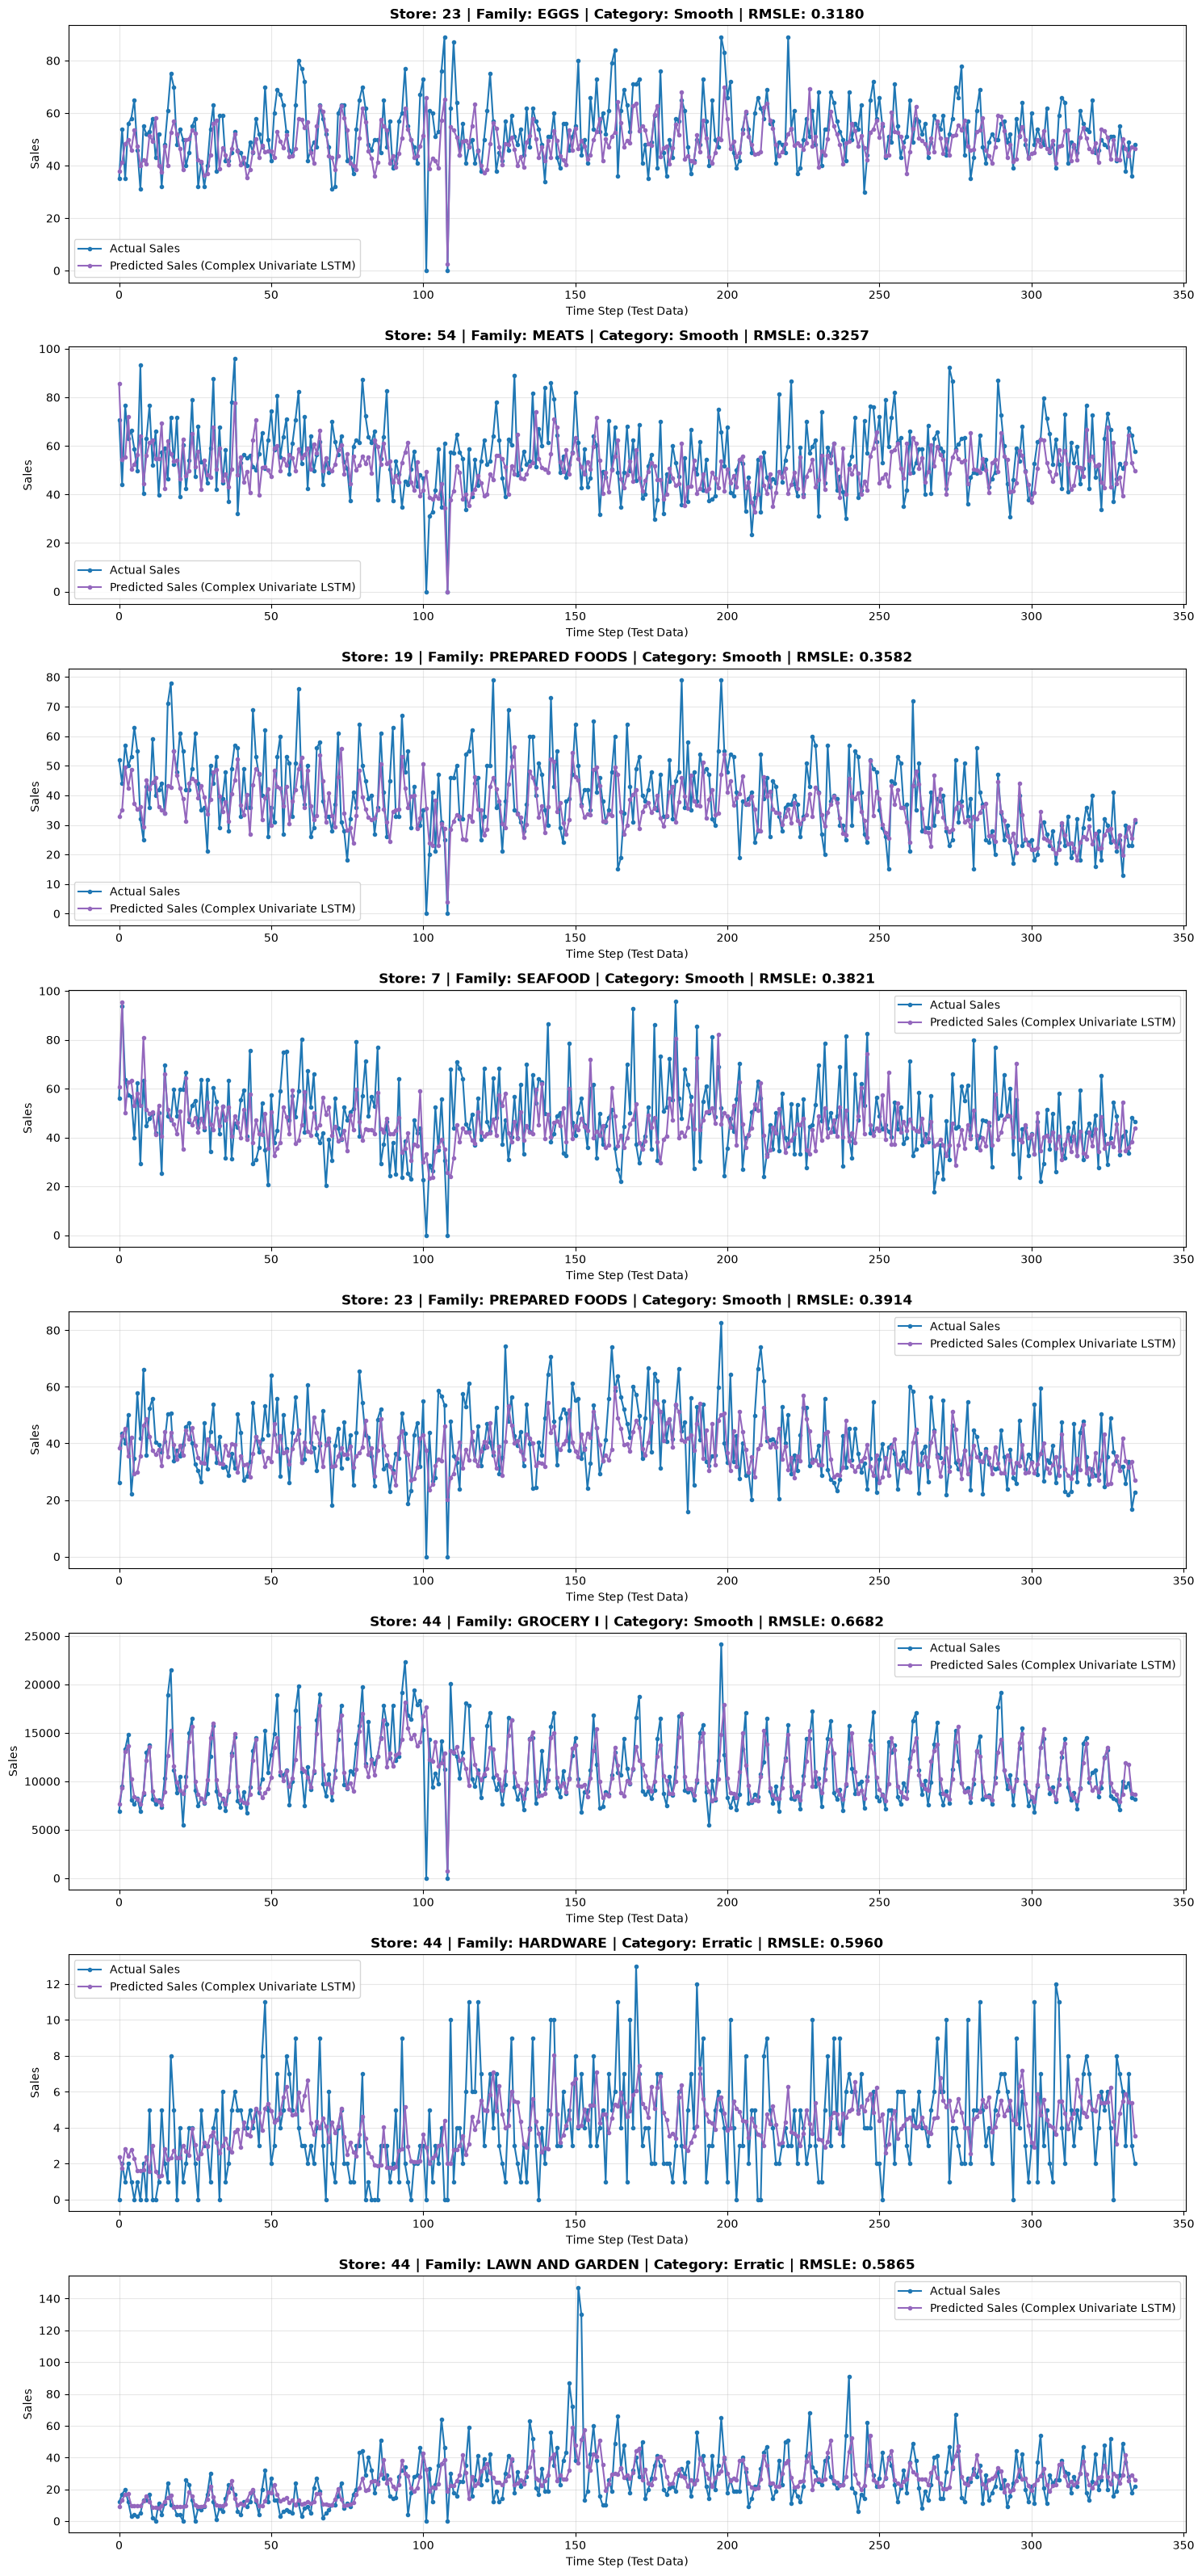

In [28]:
# 4. Visualisasi 8 Kombinasi Target (Complex Univariate LSTM)
selected_rows_complex_uv = []
for store, family in target_combos:
    row = results_complex_uv_df[(results_complex_uv_df['store_nbr'] == store) & (results_complex_uv_df['family'] == family)]
    if not row.empty:
        selected_rows_complex_uv.append(row.iloc[0])

target_results_complex_uv_df = pd.DataFrame(selected_rows_complex_uv)
print("Hasil Evaluasi untuk 8 Kombinasi Target (Complex Univariate LSTM):")
display(target_results_complex_uv_df)

# Visualisasi plot validasi aktual vs prediksi untuk 8 kombinasi target
n_targets = len(target_combos)
plt.figure(figsize=(15, 4 * n_targets))
for i, (store, family) in enumerate(target_combos, 1):
    matched_row = results_complex_uv_df[(results_complex_uv_df['store_nbr'] == store) & (results_complex_uv_df['family'] == family)]
    rmsle_val = matched_row['RMSLE'].values[0]
    cat_val = matched_row['category'].values[0]
    y_true, y_pred = plot_data_complex_uv[(store, family)]
    
    plt.subplot(n_targets, 1, i)
    plt.plot(y_true, label='Actual Sales', marker='.', color='tab:blue')
    plt.plot(y_pred, label='Predicted Sales (Complex Univariate LSTM)', marker='.', color='tab:purple')
    plt.title(f'Store: {store} | Family: {family} | Category: {cat_val} | RMSLE: {rmsle_val:.4f}', fontsize=12, fontweight='bold')
    plt.xlabel('Time Step (Test Data)')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [29]:
# 5. Komparasi Performa RMSLE: Simple Univariate vs Complex Univariate pada 8 Kombinasi Target
comparison_uv_df = pd.DataFrame({
    'Store': [s for s, f in target_combos],
    'Family': [f for s, f in target_combos],
    'Category': target_results_uv_df['category'].values,
    'RMSLE Simple Univariate': target_results_uv_df['RMSLE'].values,
    'RMSLE Complex Univariate': target_results_complex_uv_df['RMSLE'].values,
})
comparison_uv_df['Improvement (%)'] = ((comparison_uv_df['RMSLE Simple Univariate'] - comparison_uv_df['RMSLE Complex Univariate']) / comparison_uv_df['RMSLE Simple Univariate']) * 100

print("--- Tabel Komparasi RMSLE: Simple vs Complex Univariate (8 Kombinasi Target) ---")
display(comparison_uv_df)


--- Tabel Komparasi RMSLE: Simple vs Complex Univariate (8 Kombinasi Target) ---


,Store,Family,Category,RMSLE Simple Univariate,RMSLE Complex Univariate,Improvement (%)
0,23,EGGS,Smooth,0.410056,0.317997,22.450461
1,54,MEATS,Smooth,0.409536,0.325651,20.482849
2,19,PREPARED FOODS,Smooth,0.417851,0.358183,14.279821
3,7,SEAFOOD,Smooth,0.421428,0.382132,9.324525
4,23,PREPARED FOODS,Smooth,0.426994,0.391413,8.333012
5,44,GROCERY I,Smooth,0.776069,0.668183,13.901642
6,44,HARDWARE,Erratic,0.597321,0.595950,0.229457
7,44,LAWN AND GARDEN,Erratic,0.597753,0.586546,1.874970


## 3. LSTM Multivariat


### Eksperimen Model LSTM Multivariat Sederhana (1 Layer + 11 Fitur)


In [ ]:
# 1. Memuat dan Memproses Data Eksternal
oil = pd.read_csv('../datasets/oil.csv', parse_dates=['date'])
holidays = pd.read_csv('../datasets/holidays_events.csv', parse_dates=['date'])
stores = pd.read_csv('../datasets/stores.csv')

# 1.1 Preprocessing Harga Minyak Mentah (WTI) dengan interpolasi linear kalender lengkap
oil_complete = pd.DataFrame({'date': pd.date_range(train['date'].min(), train['date'].max())})
oil_complete = oil_complete.merge(oil, on='date', how='left')
oil_complete['oil_price'] = oil_complete['dcoilwtico'].interpolate(method='linear').bfill().ffill()
oil_complete = oil_complete[['date', 'oil_price']]

# 1.2 Preprocessing Hari Libur Non-Transfer (Locale-Aware: National, Regional, Local)
valid_holidays = holidays[holidays['transferred'] == False].copy()
nat_h = set(valid_holidays[valid_holidays['locale'] == 'National']['date'].unique())

reg_h_map = {}
for state in stores['state'].unique():
    reg_h_map[state] = set(valid_holidays[(valid_holidays['locale'] == 'Regional') & (valid_holidays['locale_name'] == state)]['date'].unique())

loc_h_map = {}
for city in stores['city'].unique():
    loc_h_map[city] = set(valid_holidays[(valid_holidays['locale'] == 'Local') & (valid_holidays['locale_name'] == city)]['date'].unique())

# 1.3 Mapping Karakteristik Toko (Cluster, City, State)
store_lookup = stores.set_index('store_nbr')[['city', 'state', 'cluster']].to_dict('index')

# 1.4 Definisi Fitur Multivariat (Target 'sales' di indeks 0 + 10 Fitur Prediktif)
feature_cols = [
    'sales', 
    'onpromotion', 
    'promo_rolling_mean_7', 
    'oil_price', 
    'is_holiday', 
    'is_weekend', 
    'is_payday', 
    'day_sin', 
    'day_cos', 
    'sales_lag_7', 
    'cluster'
]
NUM_FEATURES = len(feature_cols)

print(f"Total {NUM_FEATURES} Fitur Multivariat yang digunakan:")
for i, col in enumerate(feature_cols):
    print(f"  {i}. {col}")


In [ ]:
# 2. Pembuatan Data Sequence Multivariat (Feature Extraction, Pooling & Dual Scaling) untuk 1.782 Kombinasi
TIME_STEPS = 14

pivoted_sales = train.pivot(index='date', columns=['store_nbr', 'family'], values='sales').asfreq('D').fillna(0)
pivoted_promo = train.pivot(index='date', columns=['store_nbr', 'family'], values='onpromotion').asfreq('D').fillna(0)
dates = pivoted_sales.index

# Prekomputasi fitur berbasis tanggal
oil_series = oil_complete.set_index('date').reindex(dates)['oil_price'].values.astype(np.float32)
dayofweek = dates.dayofweek.values
is_weekend = (dayofweek >= 5).astype(np.float32)
is_payday = ((dates.day == 15) | dates.is_month_end).astype(np.float32)
day_sin = np.sin(2 * np.pi * dayofweek / 7).astype(np.float32)
day_cos = np.cos(2 * np.pi * dayofweek / 7).astype(np.float32)

pooled_X_mv, pooled_y_mv = [], []
scalers_mv = {}         # Scaler untuk seluruh fitur input (X)
scalers_target_mv = {}  # Scaler khusus target sales (y) untuk inverse transform presisi
combo_slice_indices_mv = {}

print(f"Memulai ekstraksi {NUM_FEATURES} fitur untuk seluruh {len(all_combinations)} kombinasi...")

current_idx_mv = 0
for idx, (store, family, cat) in enumerate(all_combinations.itertuples(index=False)):
    s_info = store_lookup[store]
    store_city = s_info['city']
    store_state = s_info['state']
    store_cluster = float(s_info['cluster'])

    store_holidays = nat_h.union(reg_h_map.get(store_state, set())).union(loc_h_map.get(store_city, set()))
    is_holiday = pd.Series(dates).isin(store_holidays).astype(np.float32).values

    sales_arr = pivoted_sales[(store, family)].values.astype(np.float32)
    promo_arr = pivoted_promo[(store, family)].values.astype(np.float32)
    promo_rolling_7 = pd.Series(promo_arr).rolling(7, min_periods=1).mean().values.astype(np.float32)
    sales_lag_7 = pd.Series(sales_arr).shift(7).bfill().values.astype(np.float32)
    cluster_arr = np.full(len(dates), store_cluster, dtype=np.float32)

    # Gabungkan seluruh 11 fitur
    data_mat = np.column_stack([
        sales_arr,
        promo_arr,
        promo_rolling_7,
        oil_series,
        is_holiday,
        is_weekend,
        is_payday,
        day_sin,
        day_cos,
        sales_lag_7,
        cluster_arr
    ])

    if len(data_mat) < TIME_STEPS + 20:
        continue

    # Normalisasi Fitur Input (X)
    scaler_feat = MinMaxScaler()
    data_scaled = scaler_feat.fit_transform(data_mat).astype(np.float32)
    scalers_mv[(store, family)] = scaler_feat

    # Normalisasi Target Sales (y) secara terpisah
    scaler_tgt = MinMaxScaler()
    scaler_tgt.fit(sales_arr.reshape(-1, 1))
    scalers_target_mv[(store, family)] = scaler_tgt

    n_seq = len(data_scaled) - TIME_STEPS
    start_seq_idx = current_idx_mv
    split_seq_idx = current_idx_mv + int(n_seq * 0.8)
    end_seq_idx = current_idx_mv + n_seq
    combo_slice_indices_mv[(store, family)] = (start_seq_idx, split_seq_idx, end_seq_idx)
    current_idx_mv = end_seq_idx

    # Vectorized sliding window untuk data multivariat
    windows = np.lib.stride_tricks.sliding_window_view(data_scaled, (TIME_STEPS, NUM_FEATURES)).squeeze(axis=1)[:-1]
    targets = data_scaled[TIME_STEPS:, 0]

    pooled_X_mv.append(windows)
    pooled_y_mv.append(targets)

pooled_X_mv = np.concatenate(pooled_X_mv, axis=0).astype(np.float32)
pooled_y_mv = np.concatenate(pooled_y_mv, axis=0).astype(np.float32)
print(f"Selesai! Total sequences Multivariat: {len(pooled_X_mv):,} dengan shape {pooled_X_mv.shape}")
print(f"Ukuran memori array input X multivariat: {pooled_X_mv.nbytes / (1024**2):.2f} MB")


In [ ]:
# 3. Pembagian Data Train/Test Multivariat (80% Train, 20% Test Kronologis)
train_slices_mv, test_slices_mv = [], []
for store, family in all_combinations[['store_nbr', 'family']].itertuples(index=False):
    start, split, end = combo_slice_indices_mv[(store, family)]
    train_slices_mv.append(np.arange(start, split))
    test_slices_mv.append(np.arange(split, end))

train_idx_mv = np.concatenate(train_slices_mv)
test_idx_mv = np.concatenate(test_slices_mv)

X_train_mv, y_train_mv = pooled_X_mv[train_idx_mv], pooled_y_mv[train_idx_mv]
X_test_mv, y_test_mv = pooled_X_mv[test_idx_mv], pooled_y_mv[test_idx_mv]

print(f"Multivariate Train sequences: {len(X_train_mv):,} | Test sequences: {len(X_test_mv):,}")


In [ ]:
# 4. Pelatihan Model Global Multivariat LSTM Sederhana
model_mv = Sequential([
    Input(shape=(TIME_STEPS, NUM_FEATURES)),
    LSTM(64, activation='tanh', dropout=0.2),
    Dense(1)
])

model_mv.compile(optimizer='adam', loss='mse')
model_mv.summary()

early_stop_mv = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print(f"Memulai pelatihan model global multivariat ({len(X_train_mv):,} sequences)...")
history_mv = model_mv.fit(
    X_train_mv, y_train_mv,
    validation_split=0.1,
    epochs=15,
    batch_size=512,
    callbacks=[early_stop_mv],
    verbose=1
)


In [ ]:
# 5. Evaluasi per Kombinasi dan Perhitungan RMSLE (Multivariat)
print("Menjalankan inferensi batch untuk seluruh data test multivariat...")
y_test_pred_mv = model_mv.predict(X_test_mv, batch_size=2048, verbose=1).flatten()

results_mv = []
plot_data_mv = {}

test_offset_mv = 0
for idx, (store, family, cat) in enumerate(all_combinations.itertuples(index=False)):
    start, split, end = combo_slice_indices_mv[(store, family)]
    n_test_combo = end - split
    
    if n_test_combo == 0:
        continue
        
    y_pred_scaled_combo = y_test_pred_mv[test_offset_mv : test_offset_mv + n_test_combo]
    y_test_scaled_combo = y_test_mv[test_offset_mv : test_offset_mv + n_test_combo]
    test_offset_mv += n_test_combo
    
    # Inverse transform menggunakan scaler target presisi
    scaler_tgt = scalers_target_mv[(store, family)]
    y_pred = scaler_tgt.inverse_transform(y_pred_scaled_combo.reshape(-1, 1)).flatten()
    y_test_combo = scaler_tgt.inverse_transform(y_test_scaled_combo.reshape(-1, 1)).flatten()
    
    y_test_safe = np.maximum(0, y_test_combo)
    y_pred_safe = np.maximum(0, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_test_safe, y_pred_safe))
    
    results_mv.append({
        'store_nbr': store,
        'family': family,
        'category': cat,
        'RMSLE': rmsle
    })
    plot_data_mv[(store, family)] = (y_test_combo, y_pred)

results_mv_df = pd.DataFrame(results_mv)
print("--- Rangkuman Evaluasi Multivariat Keseluruhan (1.782 Kombinasi) ---")
display(results_mv_df[['RMSLE']].describe())

print("\n--- Rata-rata RMSLE per Kategori Pola Permintaan (Multivariat) ---")
display(results_mv_df.groupby('category')['RMSLE'].agg(['count', 'mean', 'median', 'std', 'min', 'max']))


Hasil Evaluasi untuk 8 Kombinasi Target (Multivariate LSTM):


,store_nbr,family,category,RMSLE
505,23,EGGS,Smooth,0.389069
1641,54,MEATS,Smooth,0.383533
359,19,PREPARED FOODS,Smooth,0.398072
1715,7,SEAFOOD,Smooth,0.378754
524,23,PREPARED FOODS,Smooth,0.410586
1266,44,GROCERY I,Smooth,0.763329
1268,44,HARDWARE,Erratic,0.574267
1274,44,LAWN AND GARDEN,Erratic,0.566713


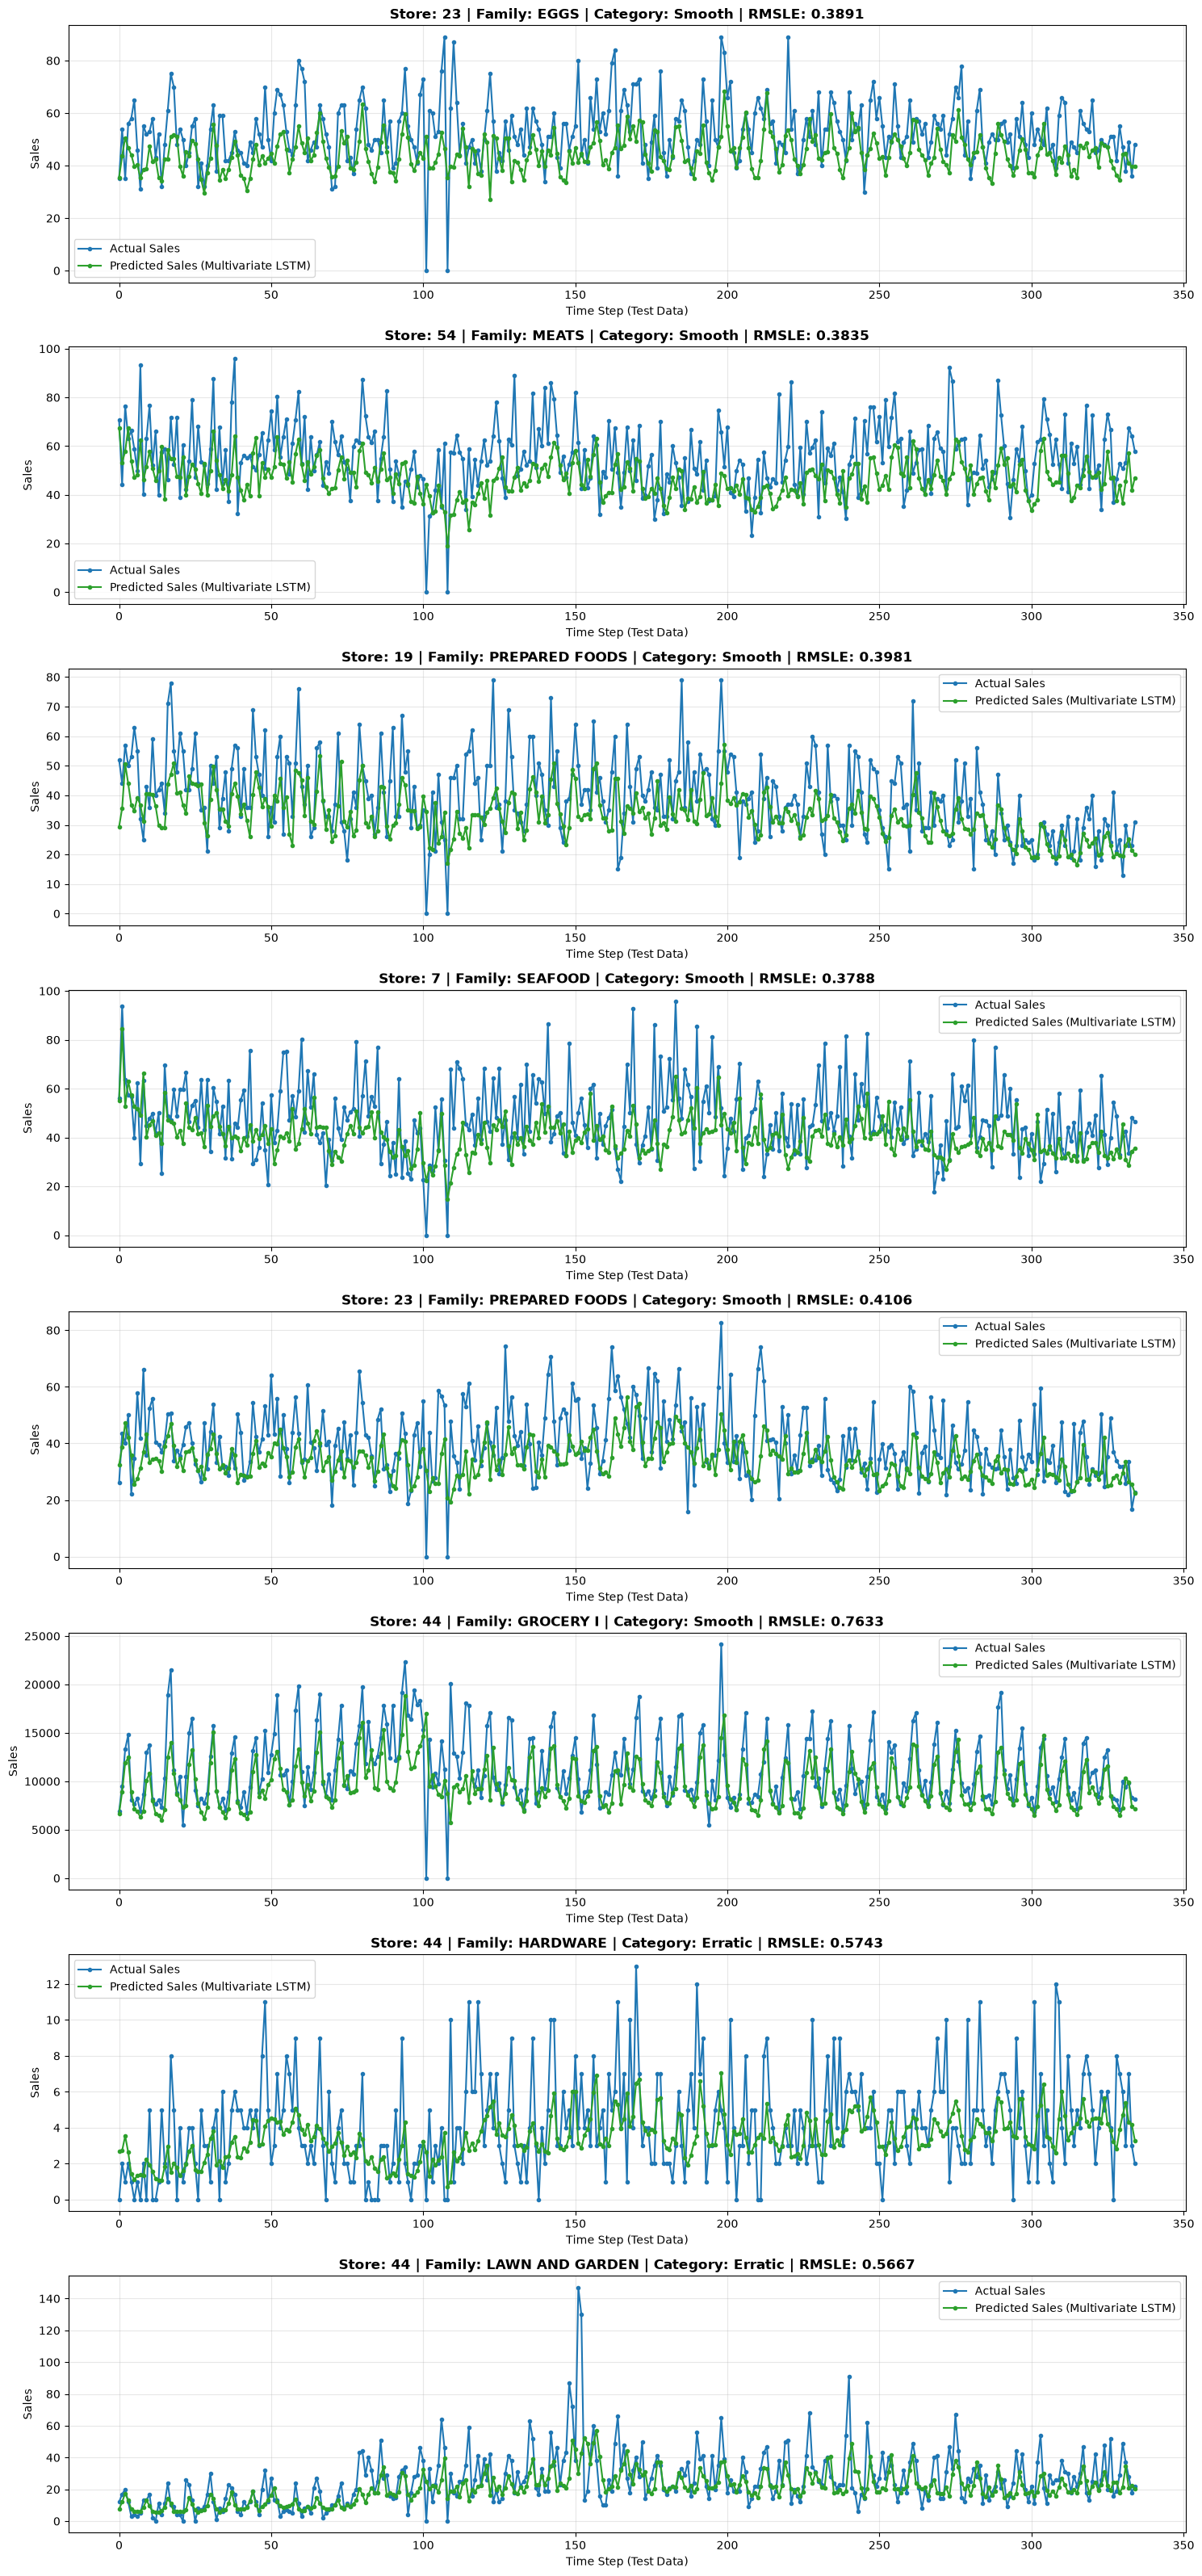

In [30]:
# 6. Visualisasi 8 Kombinasi Target (Multivariat)
selected_rows_mv = []
for store, family in target_combos:
    row = results_mv_df[(results_mv_df['store_nbr'] == store) & (results_mv_df['family'] == family)]
    if not row.empty:
        selected_rows_mv.append(row.iloc[0])

target_results_mv_df = pd.DataFrame(selected_rows_mv)
print("Hasil Evaluasi untuk 8 Kombinasi Target (Multivariate LSTM):")
display(target_results_mv_df)

# Visualisasi plot validasi aktual vs prediksi untuk 8 kombinasi target
n_targets = len(target_combos)
plt.figure(figsize=(15, 4 * n_targets))
for i, (store, family) in enumerate(target_combos, 1):
    matched_row = results_mv_df[(results_mv_df['store_nbr'] == store) & (results_mv_df['family'] == family)]
    rmsle_val = matched_row['RMSLE'].values[0]
    cat_val = matched_row['category'].values[0]
    y_true, y_pred = plot_data_mv[(store, family)]
    
    plt.subplot(n_targets, 1, i)
    plt.plot(y_true, label='Actual Sales', marker='.', color='tab:blue')
    plt.plot(y_pred, label='Predicted Sales (Multivariate LSTM)', marker='.', color='tab:green')
    plt.title(f'Store: {store} | Family: {family} | Category: {cat_val} | RMSLE: {rmsle_val:.4f}', fontsize=12, fontweight='bold')
    plt.xlabel('Time Step (Test Data)')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [31]:
# 7. Komparasi Performa RMSLE: Univariat vs Multivariat pada 8 Kombinasi Target
comparison_df = pd.DataFrame({
    'Store': [s for s, f in target_combos],
    'Family': [f for s, f in target_combos],
    'Category': target_results_uv_df['category'].values,
    'RMSLE Univariate': target_results_uv_df['RMSLE'].values,
    'RMSLE Multivariate': target_results_mv_df['RMSLE'].values,
})
comparison_df['Improvement (%)'] = ((comparison_df['RMSLE Univariate'] - comparison_df['RMSLE Multivariate']) / comparison_df['RMSLE Univariate']) * 100

print("--- Tabel Komparasi RMSLE Univariat vs Multivariat (8 Kombinasi Target) ---")
display(comparison_df)


--- Tabel Komparasi RMSLE Univariat vs Multivariat (8 Kombinasi Target) ---


,Store,Family,Category,RMSLE Univariate,RMSLE Multivariate,Improvement (%)
0,23,EGGS,Smooth,0.410056,0.389069,5.118074
1,54,MEATS,Smooth,0.409536,0.383533,6.349224
2,19,PREPARED FOODS,Smooth,0.417851,0.398072,4.733590
3,7,SEAFOOD,Smooth,0.421428,0.378754,10.126103
4,23,PREPARED FOODS,Smooth,0.426994,0.410586,3.842792
5,44,GROCERY I,Smooth,0.776069,0.763329,1.641534
6,44,HARDWARE,Erratic,0.597321,0.574267,3.859585
7,44,LAWN AND GARDEN,Erratic,0.597753,0.566713,5.192888


### Eksperimen Model LSTM Multivariat Kompleks (2 Layer + Dropout + Dense Projection + 11 Fitur)


In [ ]:
# 1. Membangun Arsitektur LSTM Multivariat Kompleks (2 Layer + Dropout + Dense Projection)
model_complex_mv = Sequential([
    Input(shape=(TIME_STEPS, NUM_FEATURES)),
    LSTM(128, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(64, activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_complex_mv.compile(optimizer='adam', loss='mse')
model_complex_mv.summary()


In [ ]:
# 2. Pelatihan Model Global Complex Multivariate LSTM
early_stop_complex_mv = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr_complex_mv = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)

print(f"Memulai pelatihan model global Complex Multivariate LSTM ({len(X_train_mv):,} sequences)...")
history_complex_mv = model_complex_mv.fit(
    X_train_mv, y_train_mv,
    validation_split=0.1,
    epochs=15,
    batch_size=512,
    callbacks=[early_stop_complex_mv, reduce_lr_complex_mv],
    verbose=1
)


In [ ]:
# 3. Evaluasi per Kombinasi dan Perhitungan RMSLE (Complex Multivariate)
print("Menjalankan inferensi batch untuk seluruh data test (Complex Multivariate)...")
y_test_pred_complex_mv = model_complex_mv.predict(X_test_mv, batch_size=2048, verbose=1).flatten()

results_complex_mv = []
plot_data_complex_mv = {}

test_offset_mv = 0
for idx, (store, family, cat) in enumerate(all_combinations.itertuples(index=False)):
    start, split, end = combo_slice_indices_mv[(store, family)]
    n_test_combo = end - split
    
    if n_test_combo == 0:
        continue
        
    y_pred_scaled_combo = y_test_pred_complex_mv[test_offset_mv : test_offset_mv + n_test_combo]
    y_test_scaled_combo = y_test_mv[test_offset_mv : test_offset_mv + n_test_combo]
    test_offset_mv += n_test_combo
    
    scaler_tgt = scalers_target_mv[(store, family)]
    y_pred = scaler_tgt.inverse_transform(y_pred_scaled_combo.reshape(-1, 1)).flatten()
    y_test_combo = scaler_tgt.inverse_transform(y_test_scaled_combo.reshape(-1, 1)).flatten()
    
    y_test_safe = np.maximum(0, y_test_combo)
    y_pred_safe = np.maximum(0, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_test_safe, y_pred_safe))
    
    results_complex_mv.append({
        'store_nbr': store,
        'family': family,
        'category': cat,
        'RMSLE': rmsle
    })
    plot_data_complex_mv[(store, family)] = (y_test_combo, y_pred)

results_complex_mv_df = pd.DataFrame(results_complex_mv)
print("\n--- Rangkuman Evaluasi Complex Multivariate Keseluruhan (1.782 Kombinasi) ---")
display(results_complex_mv_df[['RMSLE']].describe())

print("\n--- Rata-rata RMSLE per Kategori Pola Permintaan (Complex Multivariate) ---")
display(results_complex_mv_df.groupby('category')['RMSLE'].agg(['count', 'mean', 'median', 'std', 'min', 'max']))


Hasil Evaluasi untuk 8 Kombinasi Target (Complex Multivariate LSTM):


,store_nbr,family,category,RMSLE
505,23,EGGS,Smooth,0.378104
1641,54,MEATS,Smooth,0.382507
359,19,PREPARED FOODS,Smooth,0.393588
1715,7,SEAFOOD,Smooth,0.390601
524,23,PREPARED FOODS,Smooth,0.404219
1266,44,GROCERY I,Smooth,0.761163
1268,44,HARDWARE,Erratic,0.601433
1274,44,LAWN AND GARDEN,Erratic,0.588782


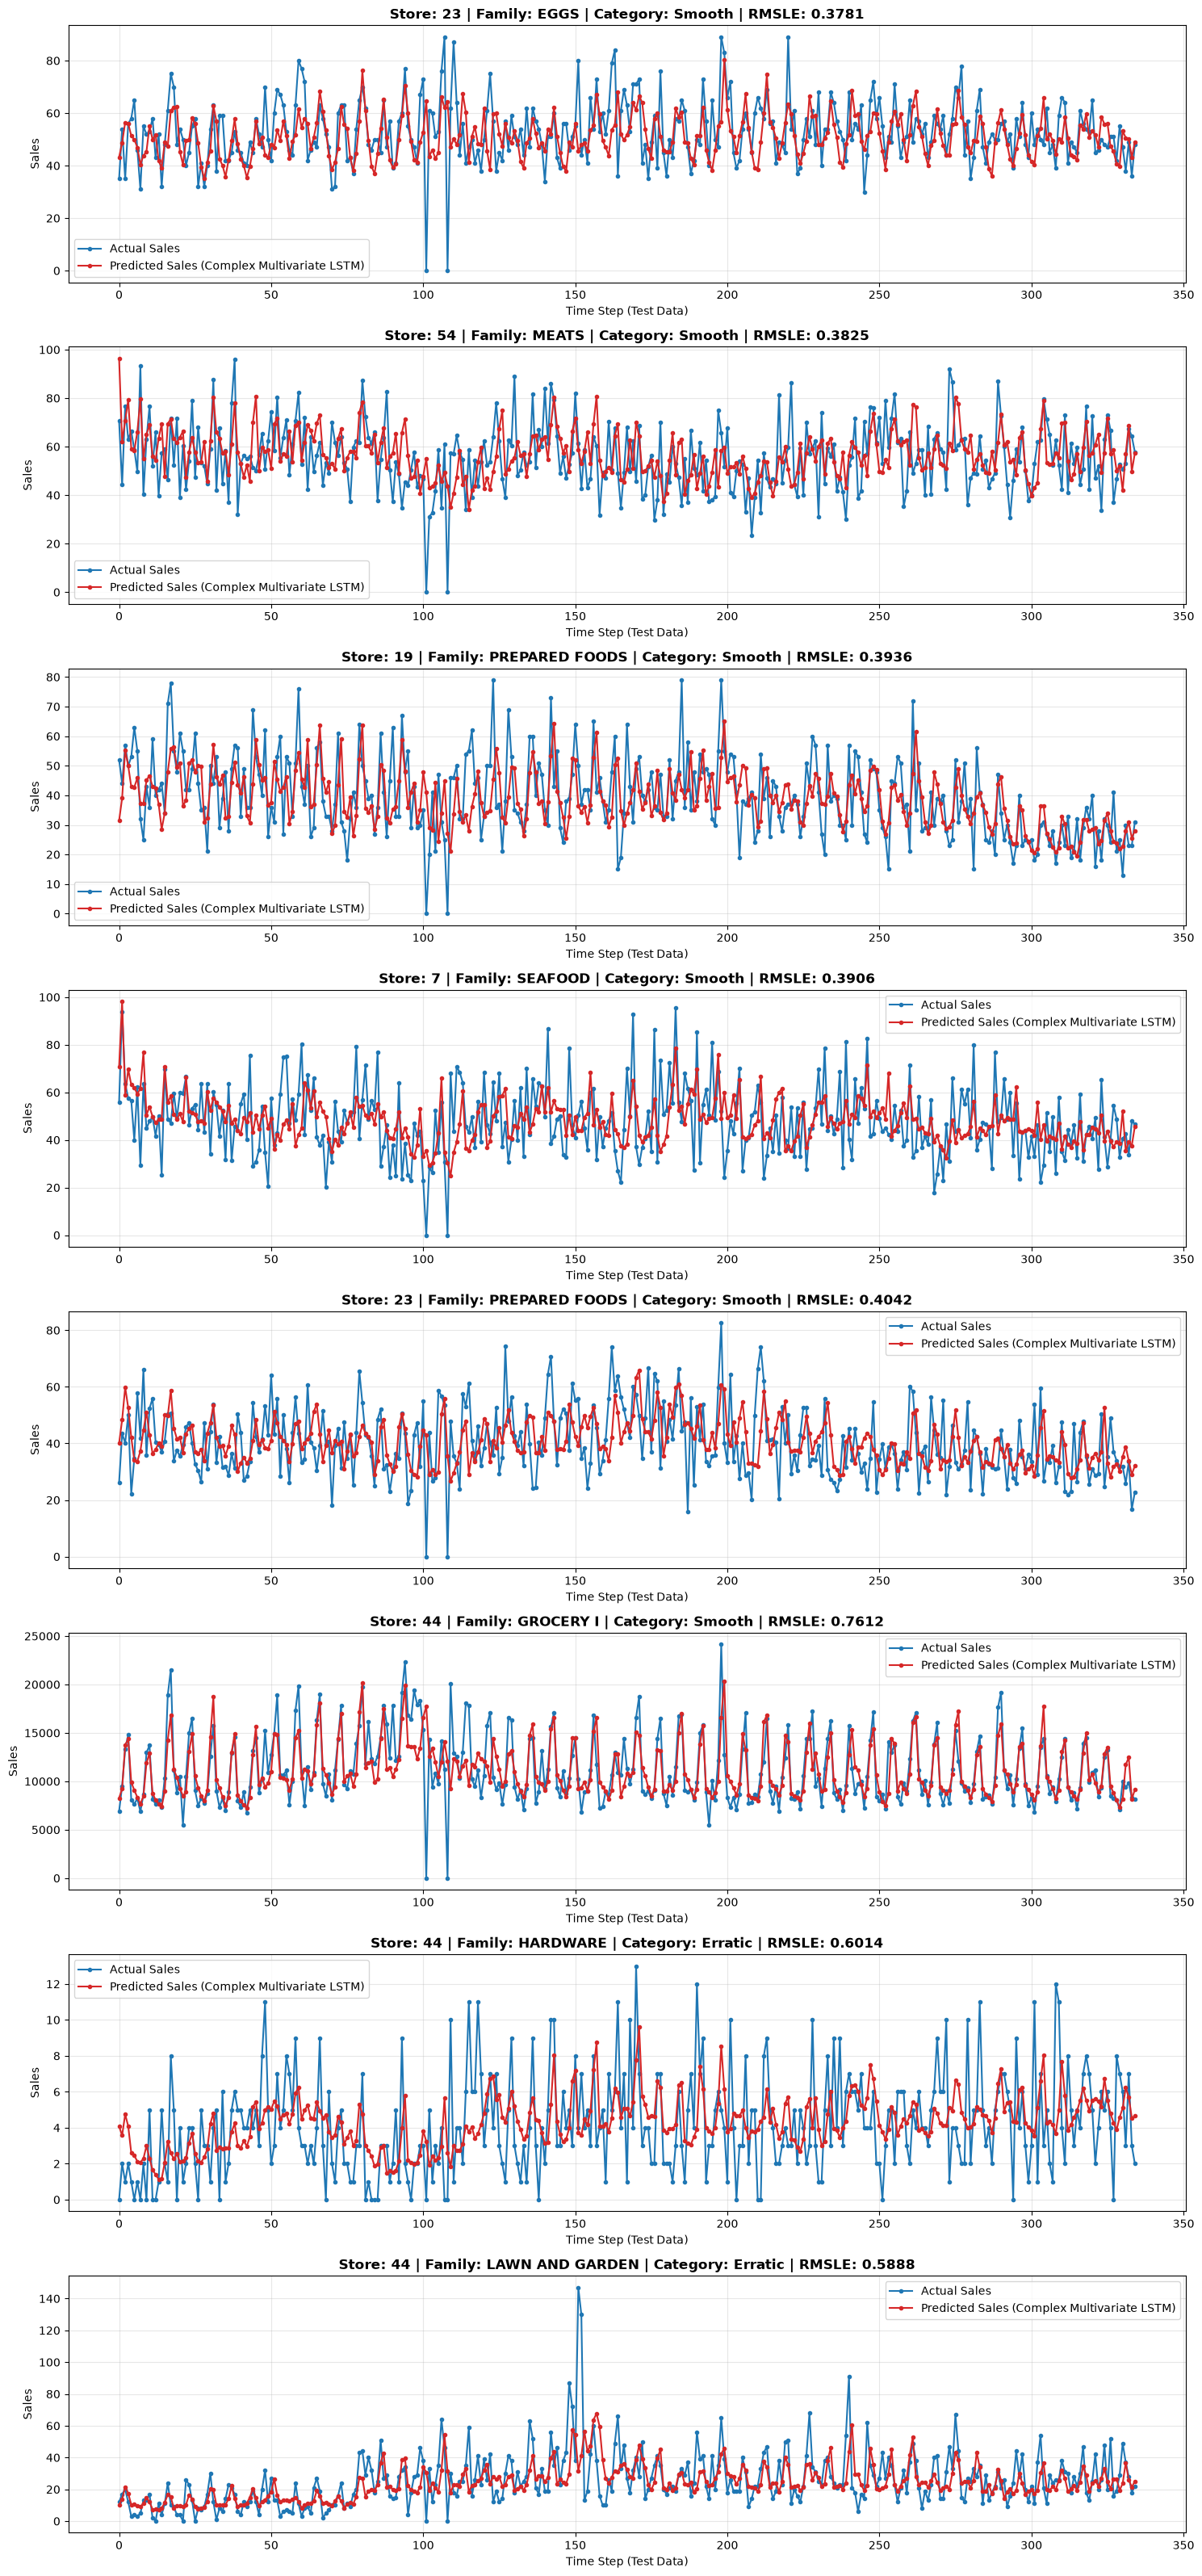

In [32]:
# 4. Visualisasi 8 Kombinasi Target (Complex Multivariate LSTM)
selected_rows_complex_mv = []
for store, family in target_combos:
    row = results_complex_mv_df[(results_complex_mv_df['store_nbr'] == store) & (results_complex_mv_df['family'] == family)]
    if not row.empty:
        selected_rows_complex_mv.append(row.iloc[0])

target_results_complex_mv_df = pd.DataFrame(selected_rows_complex_mv)
print("Hasil Evaluasi untuk 8 Kombinasi Target (Complex Multivariate LSTM):")
display(target_results_complex_mv_df)

# Visualisasi plot validasi aktual vs prediksi untuk 8 kombinasi target
n_targets = len(target_combos)
plt.figure(figsize=(15, 4 * n_targets))
for i, (store, family) in enumerate(target_combos, 1):
    matched_row = results_complex_mv_df[(results_complex_mv_df['store_nbr'] == store) & (results_complex_mv_df['family'] == family)]
    rmsle_val = matched_row['RMSLE'].values[0]
    cat_val = matched_row['category'].values[0]
    y_true, y_pred = plot_data_complex_mv[(store, family)]
    
    plt.subplot(n_targets, 1, i)
    plt.plot(y_true, label='Actual Sales', marker='.', color='tab:blue')
    plt.plot(y_pred, label='Predicted Sales (Complex Multivariate LSTM)', marker='.', color='tab:red')
    plt.title(f'Store: {store} | Family: {family} | Category: {cat_val} | RMSLE: {rmsle_val:.4f}', fontsize=12, fontweight='bold')
    plt.xlabel('Time Step (Test Data)')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [33]:
# 5. Tabel Komparasi Menyeluruh: 4 Model Global LSTM pada 8 Kombinasi Target & Seluruh Kategori
summary_target_df = pd.DataFrame({
    'Store': [s for s, f in target_combos],
    'Family': [f for s, f in target_combos],
    'Category': target_results_uv_df['category'].values,
    'RMSLE Simple UV': target_results_uv_df['RMSLE'].values,
    'RMSLE Complex UV': target_results_complex_uv_df['RMSLE'].values,
    'RMSLE Simple MV': target_results_mv_df['RMSLE'].values,
    'RMSLE Complex MV': target_results_complex_mv_df['RMSLE'].values,
})
summary_target_df['Best Model'] = summary_target_df[['RMSLE Simple UV', 'RMSLE Complex UV', 'RMSLE Simple MV', 'RMSLE Complex MV']].idxmin(axis=1).str.replace('RMSLE ', '')
summary_target_df['Best RMSLE'] = summary_target_df[['RMSLE Simple UV', 'RMSLE Complex UV', 'RMSLE Simple MV', 'RMSLE Complex MV']].min(axis=1)

print("==========================================================================================")
print("       TABEL KOMPARASI AKHIR PERFORMA RMSLE: 4 MODEL GLOBAL LSTM (8 TARGET)")
print("==========================================================================================")
display(summary_target_df)

# Komparasi Performa Rata-Rata RMSLE per Kategori untuk ke-4 Model Global
summary_category_df = pd.DataFrame({
    'Category': results_df.groupby('category')['RMSLE'].mean().index,
    'Count': results_df.groupby('category')['RMSLE'].count().values,
    'Mean RMSLE Simple UV': results_df.groupby('category')['RMSLE'].mean().values,
    'Mean RMSLE Complex UV': results_complex_uv_df.groupby('category')['RMSLE'].mean().values,
    'Mean RMSLE Simple MV': results_mv_df.groupby('category')['RMSLE'].mean().values,
    'Mean RMSLE Complex MV': results_complex_mv_df.groupby('category')['RMSLE'].mean().values,
})
summary_category_df['Best Model per Category'] = summary_category_df[['Mean RMSLE Simple UV', 'Mean RMSLE Complex UV', 'Mean RMSLE Simple MV', 'Mean RMSLE Complex MV']].idxmin(axis=1).str.replace('Mean RMSLE ', '')

print("\n==========================================================================================")
print("     TABEL KOMPARASI RATA-RATA RMSLE PER KATEGORI PERMINTAAN (4 MODEL GLOBAL)")
print("==========================================================================================")
display(summary_category_df)


       TABEL KOMPARASI AKHIR PERFORMA RMSLE: 4 MODEL GLOBAL LSTM (8 TARGET)


,Store,Family,Category,RMSLE Simple UV,RMSLE Complex UV,RMSLE Simple MV,RMSLE Complex MV,Best Model,Best RMSLE
0,23,EGGS,Smooth,0.410056,0.317997,0.389069,0.378104,Complex UV,0.317997
1,54,MEATS,Smooth,0.409536,0.325651,0.383533,0.382507,Complex UV,0.325651
2,19,PREPARED FOODS,Smooth,0.417851,0.358183,0.398072,0.393588,Complex UV,0.358183
3,7,SEAFOOD,Smooth,0.421428,0.382132,0.378754,0.390601,Simple MV,0.378754
4,23,PREPARED FOODS,Smooth,0.426994,0.391413,0.410586,0.404219,Complex UV,0.391413
5,44,GROCERY I,Smooth,0.776069,0.668183,0.763329,0.761163,Complex UV,0.668183
6,44,HARDWARE,Erratic,0.597321,0.595950,0.574267,0.601433,Simple MV,0.574267
7,44,LAWN AND GARDEN,Erratic,0.597753,0.586546,0.566713,0.588782,Simple MV,0.566713



     TABEL KOMPARASI RATA-RATA RMSLE PER KATEGORI PERMINTAAN (4 MODEL GLOBAL)


,Category,Count,Mean RMSLE Simple UV,Mean RMSLE Complex UV,Mean RMSLE Simple MV,Mean RMSLE Complex MV,Best Model per Category
0,Erratic,235,0.847608,0.783292,0.775228,0.832896,Simple MV
1,Intermittent,541,0.628017,0.539746,0.540614,0.489810,Complex MV
2,Lumpy,323,0.828193,0.694386,0.646859,0.625449,Complex MV
3,No Sales,53,0.068531,0.016997,0.014921,0.002126,Complex MV
4,Smooth,630,0.619234,0.522231,0.574307,0.556167,Complex UV
